In [324]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

In [271]:
df = pd.read_csv("C:/Users/이민정/Desktop/부트캠프/파이널프로젝트/전처리/4_청구입금정보_segment_병합.csv")
df

,Segment,기준년월,ID,대표결제일,대표결제방법코드,대표청구지고객주소구분코드,대표청구서수령지구분코드,청구서수령방법,청구서발송여부_B0,청구서발송여부_R3M,...,할인금액_청구서_B0M,상환개월수_결제일_R6M,상환개월수_결제일_R3M,선결제건수_R6M,선결제건수_R3M,연체건수_R6M,연체건수_R3M,혜택수혜금액_R3M,포인트_마일리지_환산_B0M,혜택수혜금액
0,3,201807,0,27,0,0,2,2,1,1,...,0,5,3,0,0,1,0,3,0,0
1,4,201807,1,13,0,1,5,4,1,1,...,163,6,3,0,0,0,0,0,0,0
2,2,201807,2,1,0,0,6,5,1,1,...,0,6,3,0,0,0,0,121,0,50
3,3,201807,3,5,0,1,5,4,1,1,...,0,5,3,2,0,0,0,3,0,2
4,4,201807,4,13,0,1,5,4,0,1,...,0,1,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,4,201812,399995,25,0,1,5,4,0,0,...,0,0,0,0,0,0,0,0,0,0
2399996,3,201812,399996,20,0,0,6,5,1,1,...,0,6,3,0,0,0,0,164,0,53
2399997,2,201812,399997,20,0,2,5,4,1,1,...,0,6,3,0,0,0,0,0,0,0
2399998,4,201812,399998,20,0,1,5,4,0,0,...,0,0,0,0,0,0,0,0,0,0


### 결제, 청구서수령

In [31]:
# 대표결제일
col1 = df.groupby('Segment')['대표결제일'].first().reset_index()
col1['대표결제일'] = col1['대표결제일'].apply(sorted)
col1

,Segment,대표결제일
0,0,"[1, 5, 12, 13, 15, 20, 23, 25, 27]"
1,1,"[1, 5, 12, 13, 15, 20, 23, 25, 27]"
2,2,"[1, 5, 12, 13, 15, 20, 21, 23, 25, 27]"
3,3,"[1, 5, 10, 12, 13, 15, 20, 21, 23, 25, 27]"
4,4,"[1, 5, 10, 12, 13, 15, 20, 21, 23, 25, 27]"


In [27]:
# 10일은 D와 E만 존재하며 21일은 C D E만 존재한다.

In [43]:
#대표결제방법코드
print(df['대표결제방법코드'].value_counts()) # 필요없는 컬럼

대표결제방법코드
0    2400000
Name: count, dtype: int64


In [59]:
#대표청구지고객주소구분코드

col3=pd.crosstab(df['Segment'], df['대표청구지고객주소구분코드'],normalize='index')
col3 # 필요 없는 컬럼 

대표청구지고객주소구분코드,0,1,2
Segment,,,
0,0.552469,0.301440,0.146091
1,0.666667,0.208333,0.125000
2,0.575116,0.321162,0.103723
3,0.548811,0.356372,0.094817
4,0.446486,0.446332,0.107182


In [67]:
# 대표청구서수령지구분코드

col4=pd.crosstab(df['Segment'], df['대표청구서수령지구분코드'],normalize='index')
col4 # 필요 없는 컬럼

대표청구서수령지구분코드,0,1,2,3,4,5,6
Segment,,,,,,,
0,0.010288,0.000000,0.057613,0.000000e+00,0.006173,0.455761,0.470165
1,0.020833,0.000000,0.145833,0.000000e+00,0.000000,0.333333,0.500000
2,0.023615,0.000071,0.088393,0.000000e+00,0.015965,0.428129,0.443828
3,0.025040,0.000014,0.107576,0.000000e+00,0.017409,0.453708,0.396252
4,0.014023,0.000014,0.101087,5.202773e-07,0.016979,0.555248,0.312650


In [73]:
#청구서수령방법
col5 = pd.crosstab(df['Segment'],df['청구서수령방법'],normalize='index')
col5 # 필요 없는 컬럼

청구서수령방법,0,1,2,3,4,5
Segment,,,,,,
0,0.010288,0.000000,0.057613,0.006173,0.455761,0.470165
1,0.020833,0.000000,0.145833,0.000000,0.333333,0.500000
2,0.023615,0.000071,0.088393,0.015965,0.428129,0.443828
3,0.025040,0.000014,0.107576,0.017409,0.453708,0.396252
4,0.014023,0.000014,0.101087,0.016979,0.555248,0.312650


### 청구서발송여부

In [79]:
# 청구서발송여부_B0
col6 = pd.crosstab(df['Segment'], df['청구서발송여부_B0'])
col6

청구서발송여부_B0,0,1
Segment,,
0,0,972
1,0,144
2,3772,123818
3,15603,333639
4,528253,1393799


In [81]:
# 청구서발송여부_R3M
col7 = pd.crosstab(df['Segment'], df['청구서발송여부_R3M'])
col7

청구서발송여부_R3M,0,1
Segment,,
0,8,964
1,0,144
2,4258,123332
3,15799,333443
4,466055,1455997


In [83]:
# 청구서발송여부_R6M
col8 = pd.crosstab(df['Segment'], df['청구서발송여부_R6M'])
col8

청구서발송여부_R6M,0,1
Segment,,
0,12,960
1,0,144
2,3793,123797
3,12751,336491
4,351123,1570929


In [ ]:
# 청구서 발송여부가 0이 아닌것은 B 뿐이다.

### 청구금액

In [89]:
# 청구금액_B0
col9 = df.groupby('Segment')['청구금액_B0'].agg(['min', 'max']).reset_index()
col9

,Segment,min,max
0,0,5854,195486
1,1,8090,191903
2,2,0,210006
3,3,0,147212
4,4,0,128119


In [91]:
# 청구금액_R3M
col10 = df.groupby('Segment')['청구금액_R3M'].agg(['min', 'max']).reset_index()
col10

,Segment,min,max
0,0,7472,508110
1,1,28996,472637
2,2,0,532261
3,3,0,391438
4,4,0,344929


In [163]:
# 청구금액_R6M
col11 = df.groupby('Segment')['청구금액_R6M'].agg(['min', 'max']).reset_index()
col11

,Segment,min,max
0,0,12056,1112355
1,1,52478,944773
2,2,0,1112355
3,3,0,1027904
4,4,0,885054


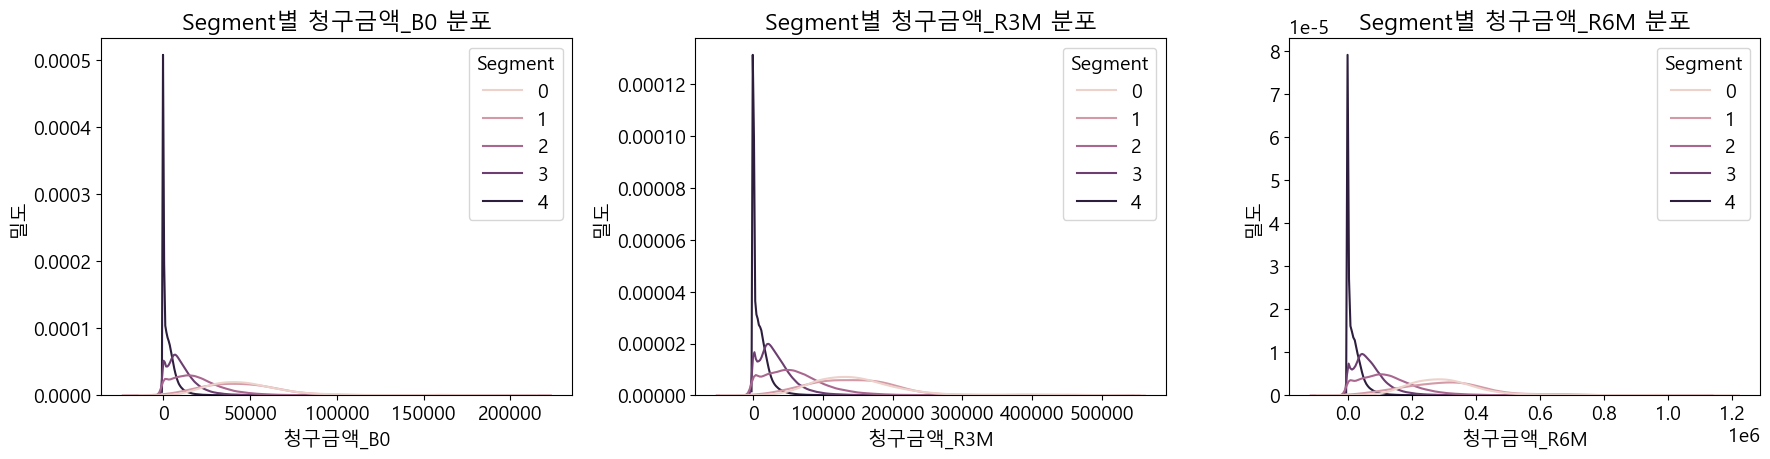

In [159]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

cols = ['청구금액_B0', '청구금액_R3M', '청구금액_R6M']

for ax, col in zip(axes, cols):
    sns.kdeplot(data=df, x=col, hue='Segment', common_norm=False, ax=ax)
    ax.set_title(f'Segment별 {col} 분포')
    ax.set_xlabel(col)
    ax.set_ylabel('밀도')

plt.tight_layout()
plt.show()

In [496]:
# cde는 0이 많음

### 포인트, 마일리지

In [169]:
# 포인트_마일리지_건별_B0M
col12 = df.groupby('Segment')['포인트_마일리지_건별_B0M'].agg(['min','max'])
col12 # 필요없는 컬럼

,min,max
Segment,,
0,0,2500
1,0,2313
2,0,3141
3,0,2706
4,0,2645


In [181]:
# 포인트_마일리지_건별_R3M
col13 = df.groupby('Segment')['포인트_마일리지_건별_R3M'].agg(['min','max'])
col13 # 필요없는 컬럼

,min,max
Segment,,
0,0,8235
1,0,6848
2,0,11404
3,0,9557
4,0,8994


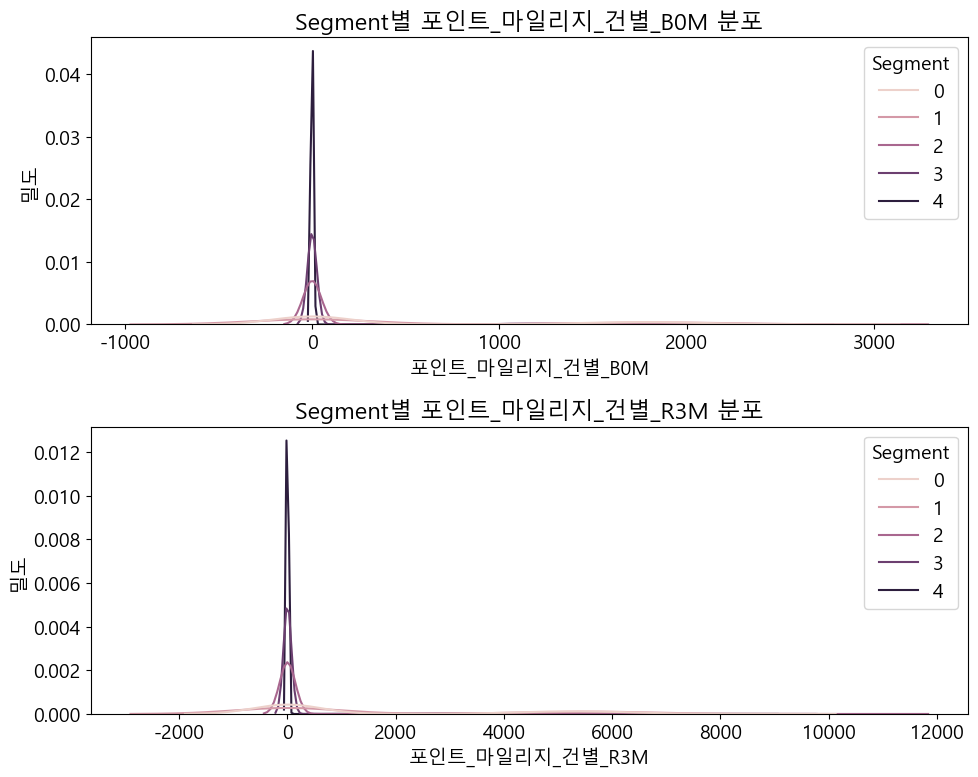

In [177]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharey=False)

cols = ['포인트_마일리지_건별_B0M', '포인트_마일리지_건별_R3M']

for ax, col in zip(axes, cols):
    sns.kdeplot(data=df, x=col, hue='Segment', common_norm=False, ax=ax)
    ax.set_title(f'Segment별 {col} 분포')
    ax.set_xlabel(col)
    ax.set_ylabel('밀도')

plt.tight_layout()
plt.show()

In [183]:
# 포인트_포인트_건별_B0M
col14 = df.groupby('Segment')['포인트_포인트_건별_B0M'].agg(['min','max'])
col14

,min,max
Segment,,
0,0,5296
1,0,5703
2,0,6622
3,0,7741
4,-63,6758


In [185]:
# 포인트_포인트_건별_R3M
col15 = df.groupby('Segment')['포인트_포인트_건별_R3M'].agg(['min','max'])
col15

,min,max
Segment,,
0,0,18751
1,0,15490
2,0,24768
3,-20,23286
4,-136,21717


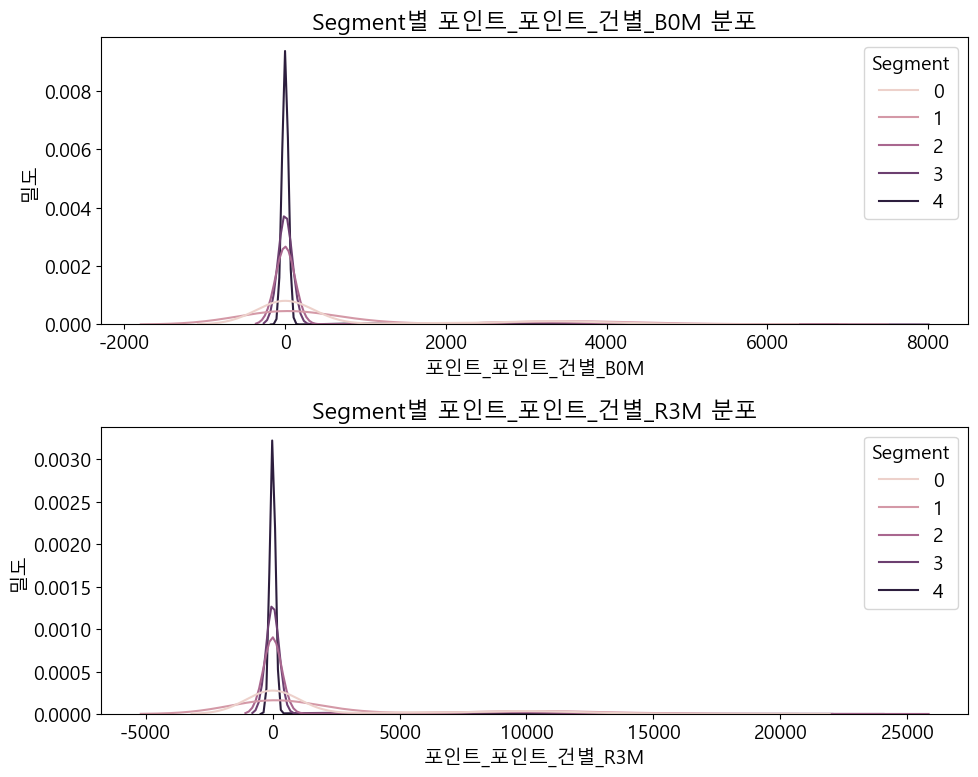

In [187]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharey=False)

cols = ['포인트_포인트_건별_B0M', '포인트_포인트_건별_R3M']

for ax, col in zip(axes, cols):
    sns.kdeplot(data=df, x=col, hue='Segment', common_norm=False, ax=ax)
    ax.set_title(f'Segment별 {col} 분포')
    ax.set_xlabel(col)
    ax.set_ylabel('밀도')

plt.tight_layout()
plt.show()

In [191]:
# 포인트_마일리지_월적립_B0M
col16 = df.groupby('Segment')['포인트_마일리지_월적립_B0M'].agg(['min','max'])
col16

,min,max
Segment,,
0,0,1221
1,0,1074
2,0,1457
3,0,1176
4,0,1311


In [193]:
# 포인트_마일리지_월적립_R3M
col17 = df.groupby('Segment')['포인트_마일리지_월적립_R3M'].agg(['min','max'])
col17

,min,max
Segment,,
0,0,4190
1,0,3471
2,0,4029
3,0,3586
4,0,3444


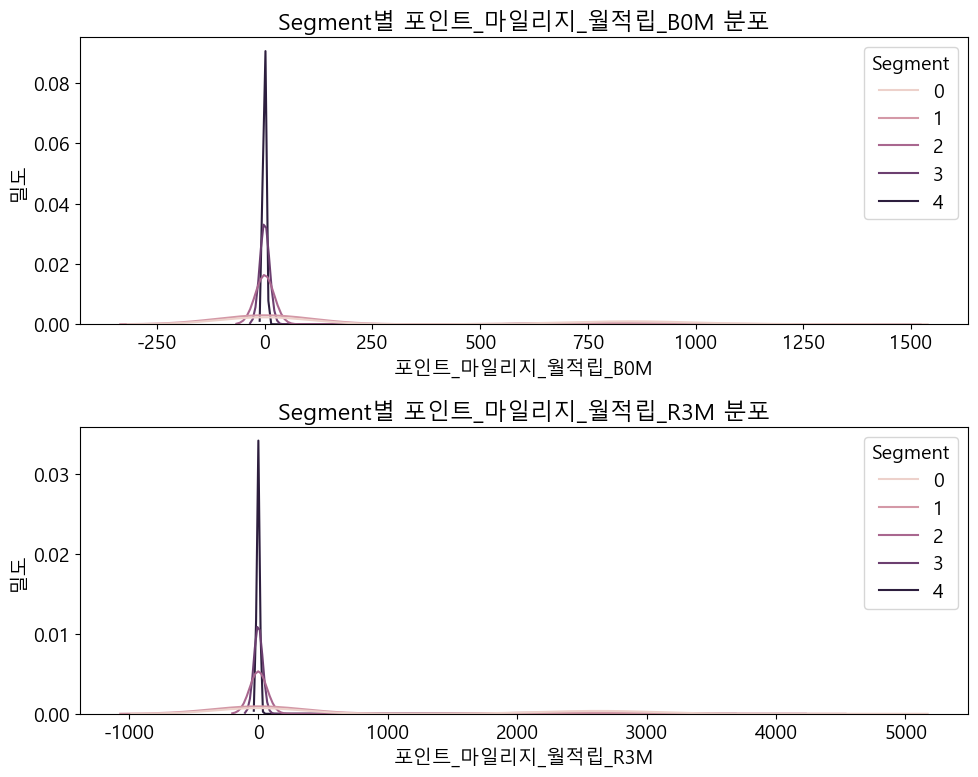

In [195]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharey=False)

cols = ['포인트_마일리지_월적립_B0M', '포인트_마일리지_월적립_R3M']

for ax, col in zip(axes, cols):
    sns.kdeplot(data=df, x=col, hue='Segment', common_norm=False, ax=ax)
    ax.set_title(f'Segment별 {col} 분포')
    ax.set_xlabel(col)
    ax.set_ylabel('밀도')

plt.tight_layout()
plt.show()

In [197]:
# 포인트_포인트_월적립_B0M
col18 = df.groupby('Segment')['포인트_포인트_월적립_B0M'].agg(['min','max'])
col18

,min,max
Segment,,
0,0,19124
1,0,19136
2,0,24854
3,0,20414
4,0,21072


In [199]:
# 포인트_포인트_월적립_R3M
col19 = df.groupby('Segment')['포인트_포인트_월적립_R3M'].agg(['min','max'])
col19

,min,max
Segment,,
0,0,37774
1,0,55740
2,0,61907
3,0,59737
4,0,59572


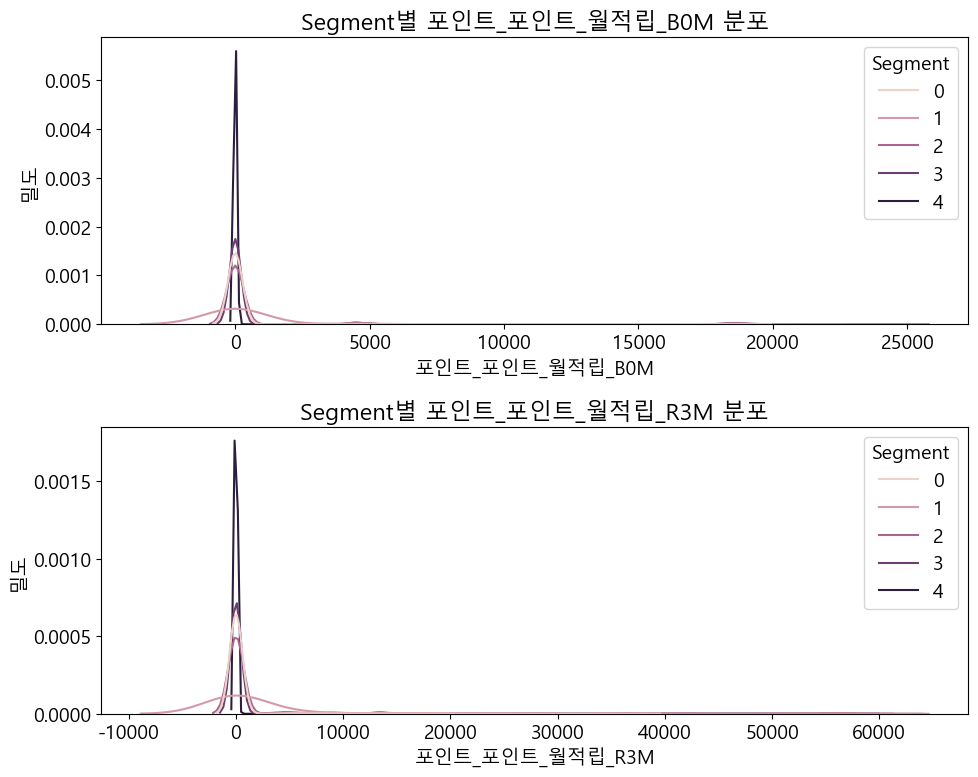

In [201]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharey=False)

cols = ['포인트_포인트_월적립_B0M', '포인트_포인트_월적립_R3M']

for ax, col in zip(axes, cols):
    sns.kdeplot(data=df, x=col, hue='Segment', common_norm=False, ax=ax)
    ax.set_title(f'Segment별 {col} 분포')
    ax.set_xlabel(col)
    ax.set_ylabel('밀도')

plt.tight_layout()
plt.show()

In [205]:
# 포인트_적립포인트_R12M
col20 = df.groupby('Segment')['포인트_적립포인트_R12M'].agg(['min','max'])
col20

,min,max
Segment,,
0,0,181347
1,0,184039
2,0,282016
3,0,324302
4,0,252357


In [203]:
# 포인트_적립포인트_R3M
col21 = df.groupby('Segment')['포인트_적립포인트_R3M'].agg(['min','max'])
col21

,min,max
Segment,,
0,0,34580
1,0,57049
2,0,76995
3,-20,69561
4,-199,72443


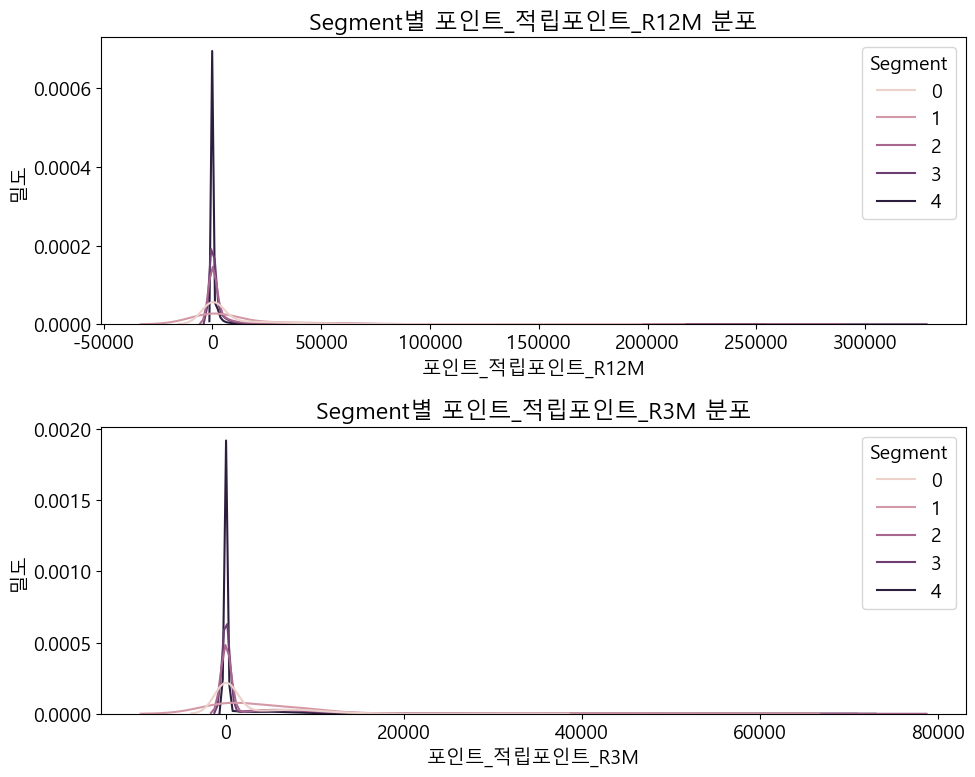

In [207]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharey=False)

cols = ['포인트_적립포인트_R12M', '포인트_적립포인트_R3M']

for ax, col in zip(axes, cols):
    sns.kdeplot(data=df, x=col, hue='Segment', common_norm=False, ax=ax)
    ax.set_title(f'Segment별 {col} 분포')
    ax.set_xlabel(col)
    ax.set_ylabel('밀도')

plt.tight_layout()
plt.show()

In [209]:
# 포인트_이용포인트_R12M
col22 = df.groupby('Segment')['포인트_이용포인트_R12M'].agg(['min','max'])
col22

,min,max
Segment,,
0,0,835029
1,0,1737161
2,0,1737161
3,0,1737161
4,0,1737161


In [211]:
# 포인트_이용포인트_R3M
col23 = df.groupby('Segment')['포인트_이용포인트_R3M'].agg(['min','max'])
col23

,min,max
Segment,,
0,0,77413
1,0,215753
2,0,229307
3,0,235303
4,-20,235914


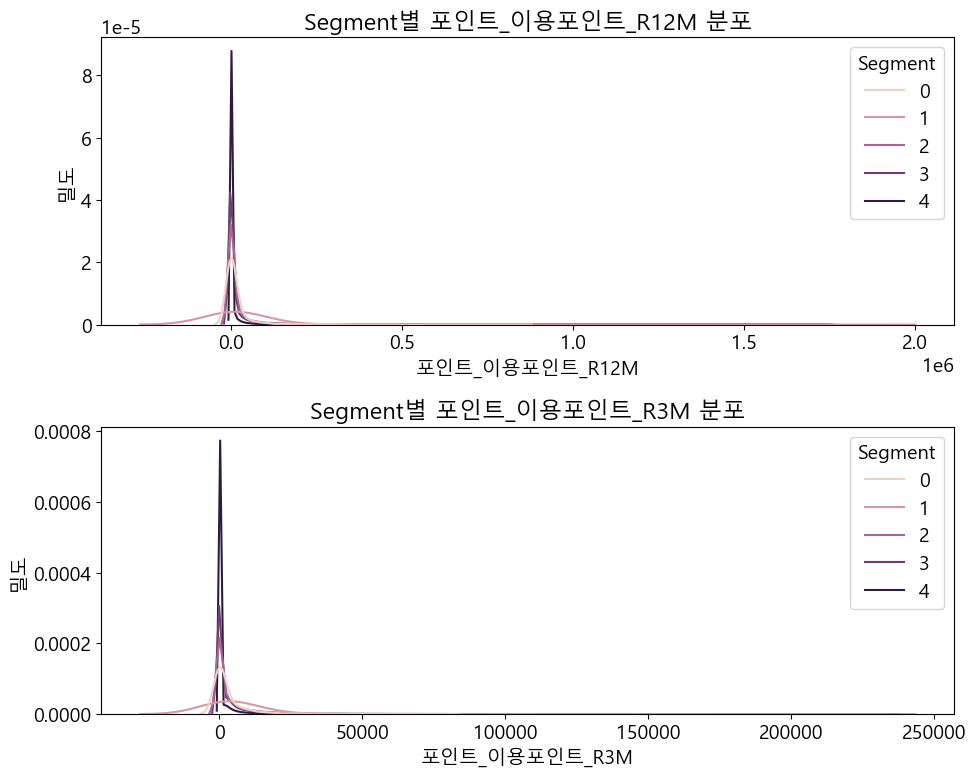

In [213]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharey=False)

cols = ['포인트_이용포인트_R12M', '포인트_이용포인트_R3M']

for ax, col in zip(axes, cols):
    sns.kdeplot(data=df, x=col, hue='Segment', common_norm=False, ax=ax)
    ax.set_title(f'Segment별 {col} 분포')
    ax.set_xlabel(col)
    ax.set_ylabel('밀도')

plt.tight_layout()
plt.show()

In [221]:
#포인트_잔여포인트_B0M
col24 = df.groupby('Segment')['포인트_잔여포인트_B0M'].agg(['min','max'])
col24

,min,max
Segment,,
0,0,0
1,0,0
2,-178,1408
3,0,2267
4,-133,1902


In [225]:
zero_counts = df.groupby('Segment')['포인트_잔여포인트_B0M'].apply(lambda x: (x == 0).sum()).reset_index()
zero_counts.columns = ['Segment', '0개수']
print(zero_counts)

   Segment      0개수
0        0      972
1        1      144
2        2   127537
3        3   349073
4        4  1920818


In [237]:
# 마일_적립포인트_R12M
col25 = df.groupby('Segment')['마일_적립포인트_R12M'].agg(['min','max'])
col25

,min,max
Segment,,
0,0,52355
1,0,51178
2,0,155923
3,0,63552
4,0,75927


In [239]:
#마일_적립포인트_R3M
col26 = df.groupby('Segment')['마일_적립포인트_R3M'].agg(['min','max'])
col26

,min,max
Segment,,
0,0,11374
1,0,8460
2,0,12144
3,0,12155
4,0,10380


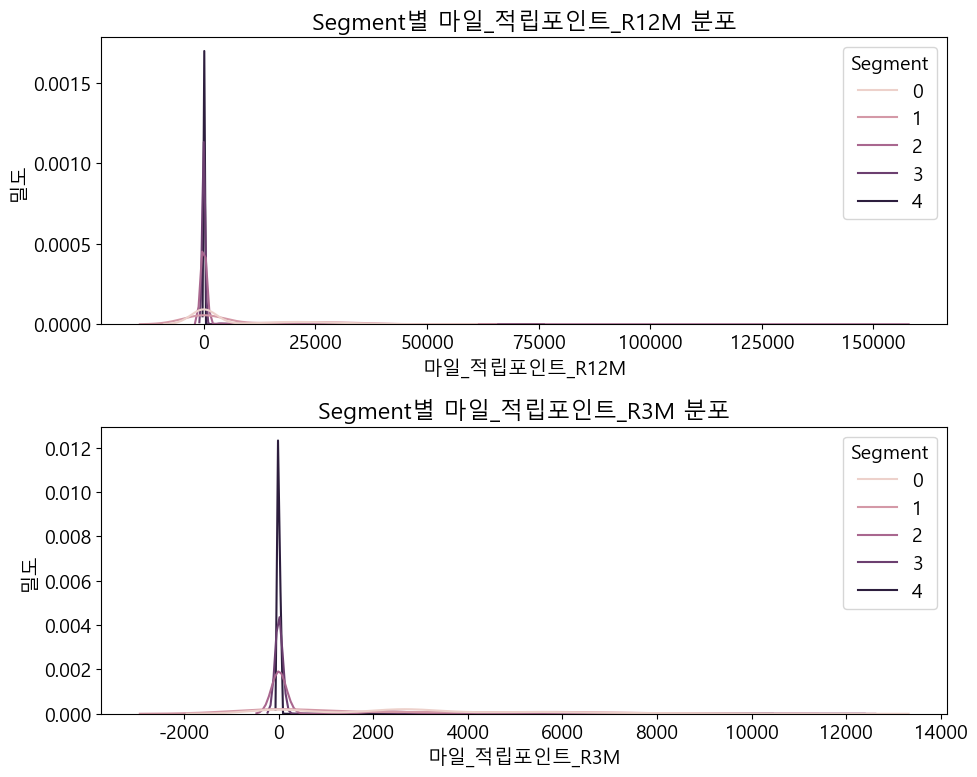

In [241]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharey=False)

cols = ['마일_적립포인트_R12M', '마일_적립포인트_R3M']

for ax, col in zip(axes, cols):
    sns.kdeplot(data=df, x=col, hue='Segment', common_norm=False, ax=ax)
    ax.set_title(f'Segment별 {col} 분포')
    ax.set_xlabel(col)
    ax.set_ylabel('밀도')

plt.tight_layout()
plt.show()

In [243]:
#마일_이용포인트_R12M
col27 = df.groupby('Segment')['마일_이용포인트_R12M'].agg(['min','max'])
col27

,min,max
Segment,,
0,0,48250
1,0,32862
2,0,42943
3,0,41319
4,0,44948


In [245]:
#마일_이용포인트_R3M
col28 = df.groupby('Segment')['마일_이용포인트_R3M'].agg(['min','max'])
col28

,min,max
Segment,,
0,0,8824
1,0,7227
2,0,9070
3,0,7914
4,0,7973


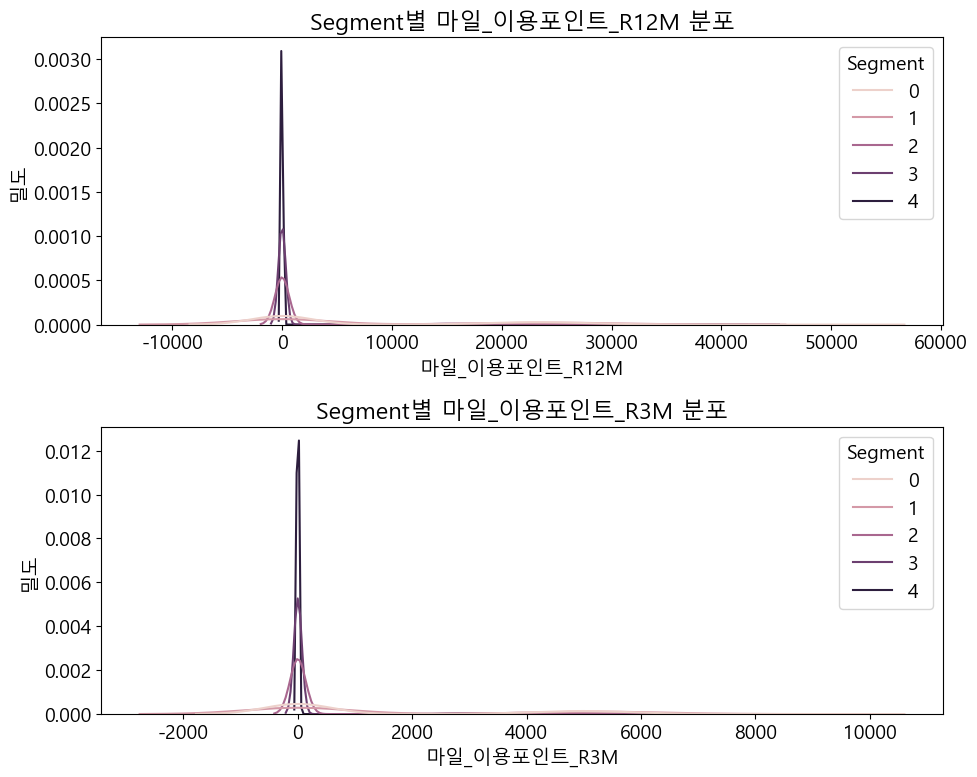

In [247]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharey=False)

cols = ['마일_이용포인트_R12M', '마일_이용포인트_R3M']

for ax, col in zip(axes, cols):
    sns.kdeplot(data=df, x=col, hue='Segment', common_norm=False, ax=ax)
    ax.set_title(f'Segment별 {col} 분포')
    ax.set_xlabel(col)
    ax.set_ylabel('밀도')

plt.tight_layout()
plt.show()

In [249]:
# 마일_잔여포인트_B0M
col29 = df.groupby('Segment')['마일_잔여포인트_B0M'].agg(['min','max'])
col29

,min,max
Segment,,
0,0,1391
1,0,1082
2,0,1419
3,0,1269
4,0,1312


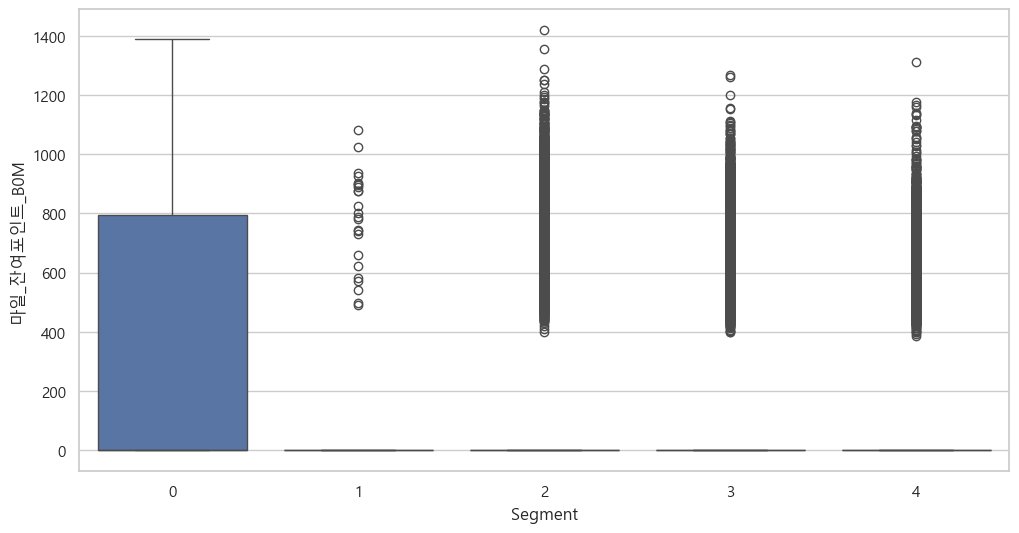

In [462]:
sns.boxplot(x='Segment', y='마일_잔여포인트_B0M', data=df)
plt.show()

In [275]:
zero_counts = df.groupby('Segment')['마일_잔여포인트_B0M'].apply(lambda x: (x == 0).sum()).reset_index()
zero_counts.columns = ['Segment', '0개수']
print(zero_counts)

   Segment      0개수
0        0      550
1        1      120
2        2   112710
3        3   330209
4        4  1895262


In [279]:
df.groupby('Segment')['마일_잔여포인트_B0M'].describe()

,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
0,972.0,355.927984,413.822903,0.0,0.0,0.0,795.0,1391.0
1,144.0,129.756944,298.507294,0.0,0.0,0.0,0.0,1082.0
2,127590.0,82.064143,228.801218,0.0,0.0,0.0,0.0,1419.0
3,349242.0,34.727163,145.951148,0.0,0.0,0.0,0.0,1269.0
4,1922052.0,8.382309,70.936423,0.0,0.0,0.0,0.0,1312.0


### 할인

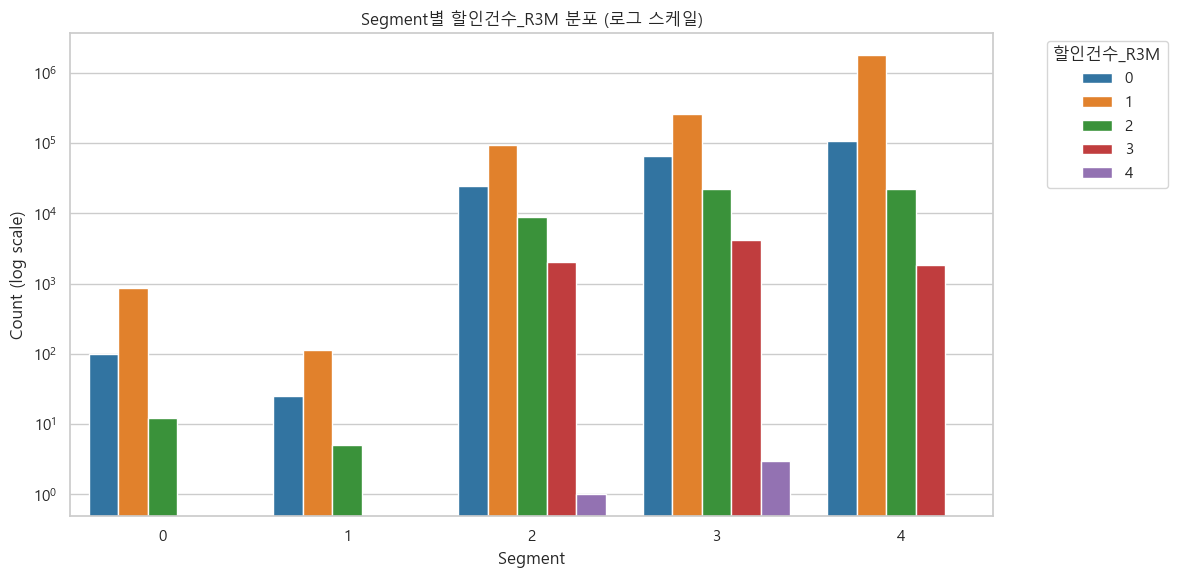

In [344]:
# col30 = 할인건수_R3M
counts_df = df.groupby('Segment')['할인건수_R3M'].value_counts().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=counts_df, x='Segment', y='count', hue='할인건수_R3M', palette='tab10')
plt.yscale('log') 
plt.title('Segment별 할인건수_R3M 분포 (로그 스케일)')
plt.xlabel('Segment')
plt.ylabel('Count (log scale)')
plt.legend(title='할인건수_R3M', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

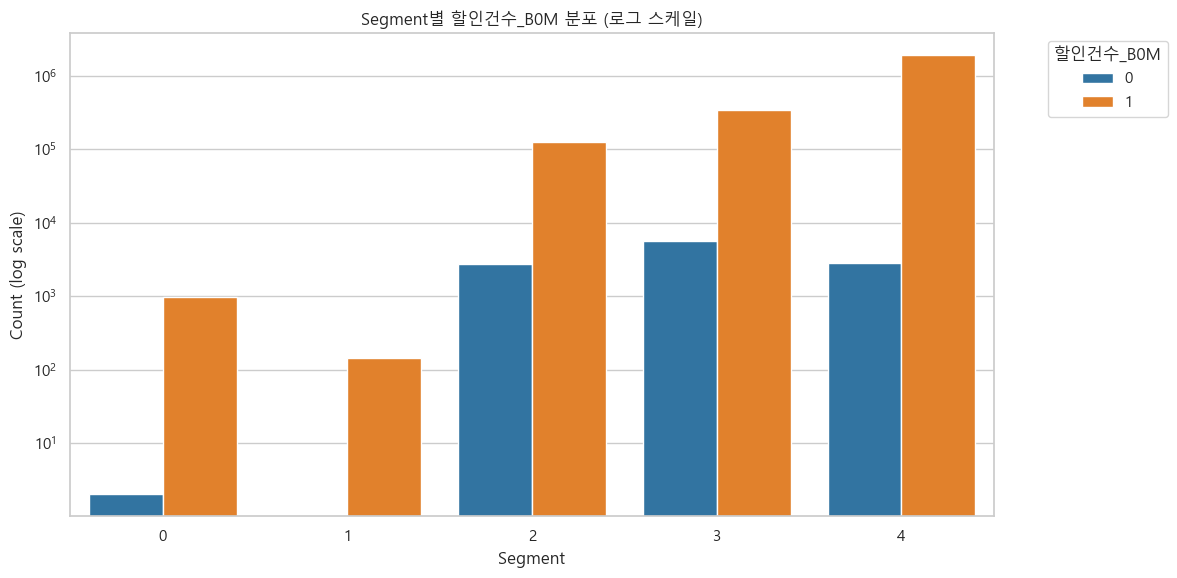

In [346]:
# col 31 = 할인건수_B0M
counts_df = df.groupby('Segment')['할인건수_B0M'].value_counts().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=counts_df, x='Segment', y='count', hue='할인건수_B0M', palette='tab10')
plt.yscale('log') 
plt.title('Segment별 할인건수_B0M 분포 (로그 스케일)')
plt.xlabel('Segment')
plt.ylabel('Count (log scale)')
plt.legend(title='할인건수_B0M', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

In [360]:
# 할인금액_R3M
col32= df.groupby('Segment')['할인금액_R3M'].agg(['min', 'max']).reset_index()
col32

,Segment,min,max
0,0,0,993
1,1,0,983
2,2,0,1358
3,3,0,1361
4,4,0,1228


In [362]:
# 할인금액_B0M
col33 = df.groupby('Segment')['할인금액_B0M'].agg(['min', 'max']).reset_index()
col33

,Segment,min,max
0,0,0,338
1,1,0,346
2,2,0,478
3,3,0,480
4,4,0,434


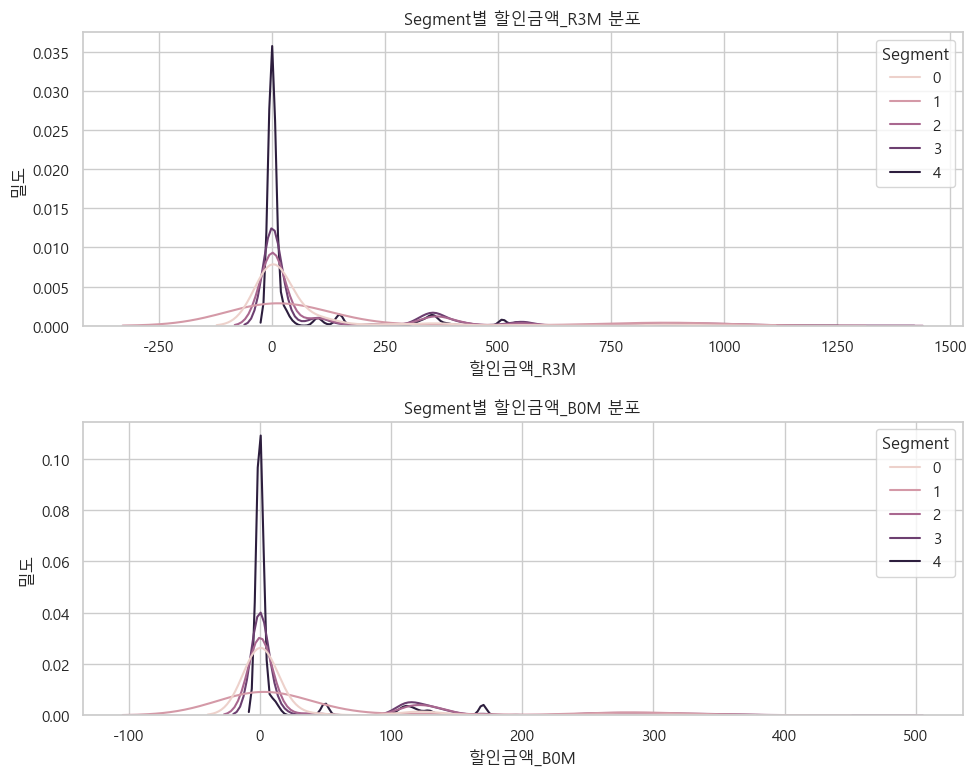

In [364]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharey=False)

cols = ['할인금액_R3M', '할인금액_B0M']

for ax, col in zip(axes, cols):
    sns.kdeplot(data=df, x=col, hue='Segment', common_norm=False, ax=ax)
    ax.set_title(f'Segment별 {col} 분포')
    ax.set_xlabel(col)
    ax.set_ylabel('밀도')

plt.tight_layout()
plt.show()

In [366]:
# 할인금액_청구서_R3M
col34 = df.groupby('Segment')['할인금액_청구서_R3M'].agg(['min', 'max']).reset_index()
col34

,Segment,min,max
0,0,0,1450
1,1,0,1454
2,2,0,1976
3,3,0,1866
4,4,0,1728


In [368]:
#할인금액_청구서_B0M
col35 = df.groupby('Segment')['할인금액_청구서_B0M'].agg(['min', 'max']).reset_index()
col35

,Segment,min,max
0,0,0,527
1,1,0,490
2,2,0,688
3,3,0,653
4,4,0,576


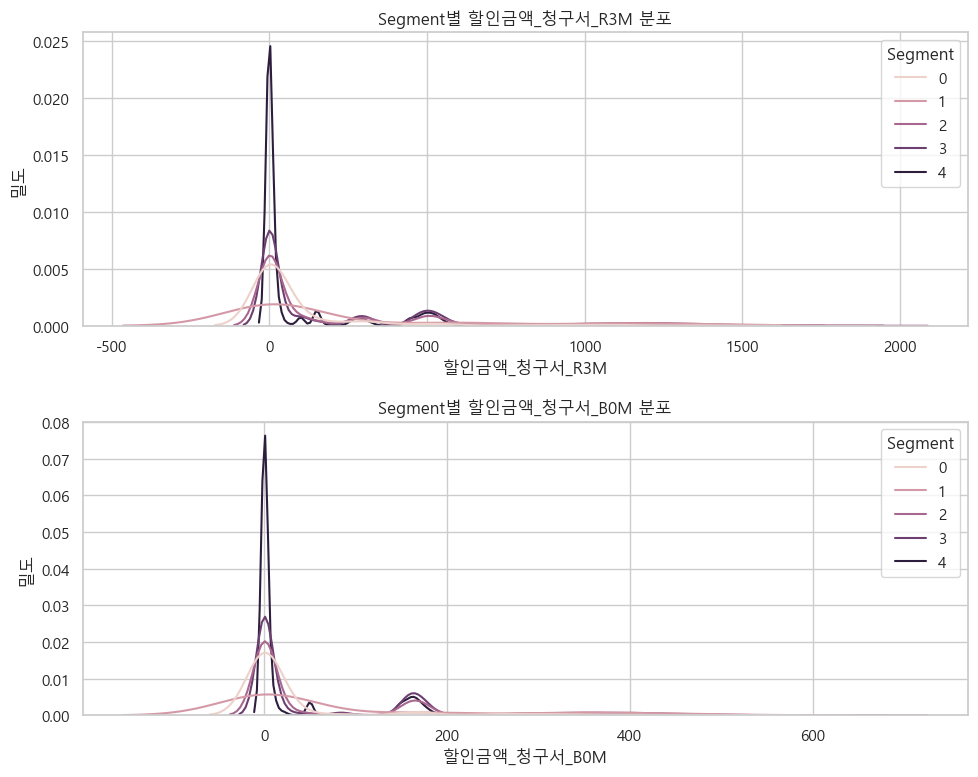

In [370]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharey=False)

cols = ['할인금액_청구서_R3M', '할인금액_청구서_B0M']

for ax, col in zip(axes, cols):
    sns.kdeplot(data=df, x=col, hue='Segment', common_norm=False, ax=ax)
    ax.set_title(f'Segment별 {col} 분포')
    ax.set_xlabel(col)
    ax.set_ylabel('밀도')

plt.tight_layout()
plt.show()

### 결제

In [390]:
#상환개월수_결제일_R6M
col36 = df.groupby('Segment')['상환개월수_결제일_R6M'].apply(list).reset_index()
col36['상환개월수_결제일_R6M'] = col36['상환개월수_결제일_R6M'].apply(lambda x: sorted(set(x)))
col36

,Segment,상환개월수_결제일_R6M
0,0,"[0, 1, 2, 3, 4, 5, 6]"
1,1,"[0, 1, 2, 3, 4, 5, 6]"
2,2,"[0, 1, 2, 3, 4, 5, 6]"
3,3,"[0, 1, 2, 3, 4, 5, 6]"
4,4,"[0, 1, 2, 3, 4, 5, 6]"


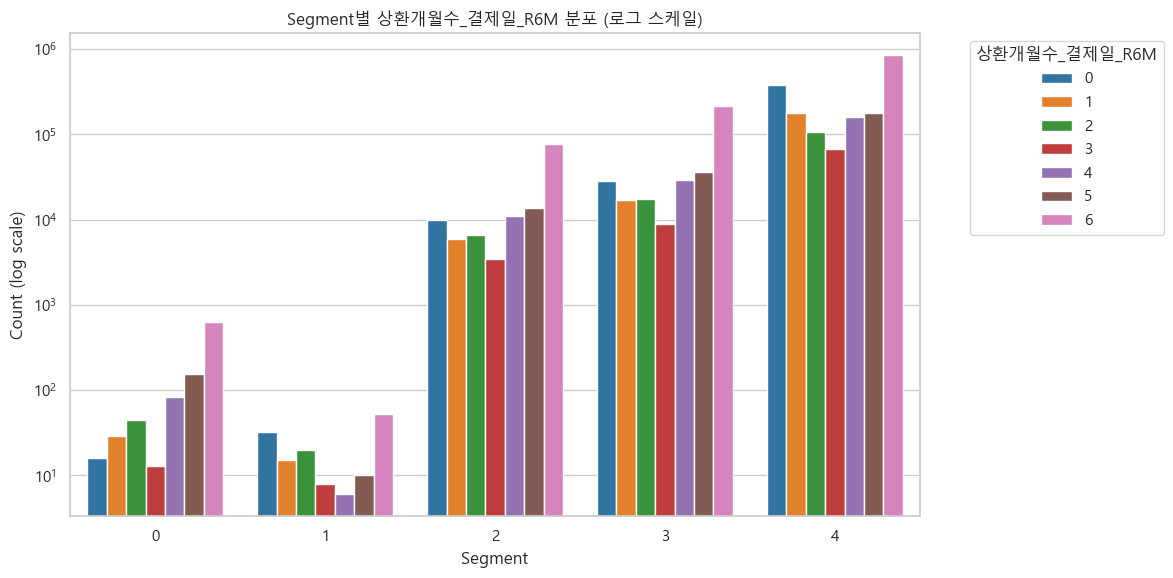

In [392]:
counts_df = df.groupby('Segment')['상환개월수_결제일_R6M'].value_counts().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=counts_df, x='Segment', y='count', hue='상환개월수_결제일_R6M', palette='tab10')
plt.yscale('log') 
plt.title('Segment별 상환개월수_결제일_R6M 분포 (로그 스케일)')
plt.xlabel('Segment')
plt.ylabel('Count (log scale)')
plt.legend(title='상환개월수_결제일_R6M', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

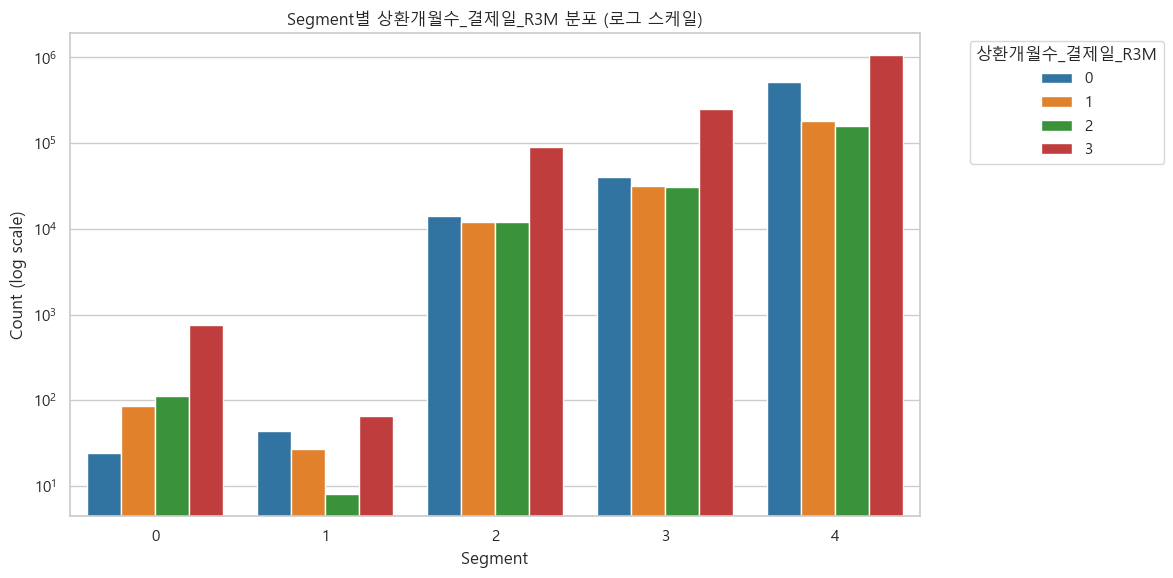

In [394]:
# 상환개월수_결제일_R3M
counts_df = df.groupby('Segment')['상환개월수_결제일_R3M'].value_counts().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=counts_df, x='Segment', y='count', hue='상환개월수_결제일_R3M', palette='tab10')
plt.yscale('log') 
plt.title('Segment별 상환개월수_결제일_R3M 분포 (로그 스케일)')
plt.xlabel('Segment')
plt.ylabel('Count (log scale)')
plt.legend(title='상환개월수_결제일_R3M', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

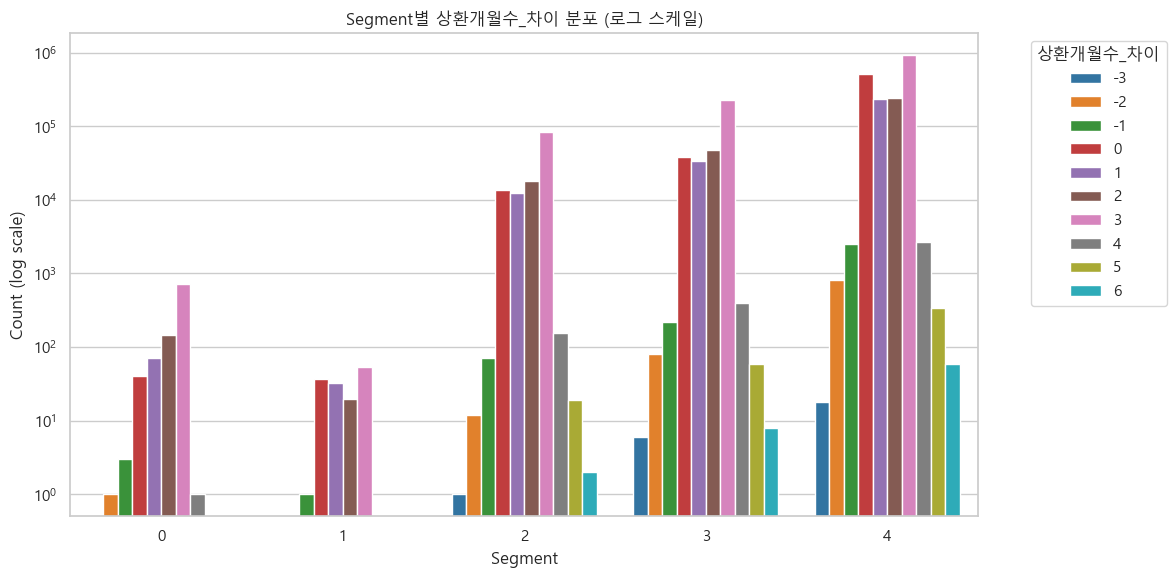

In [398]:
df['상환개월수_차이'] = df['상환개월수_결제일_R6M'] - df['상환개월수_결제일_R3M']

counts_df = df.groupby('Segment')['상환개월수_차이'].value_counts().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=counts_df, x='Segment', y='count', hue='상환개월수_차이', palette='tab10')
plt.yscale('log') 
plt.title('Segment별 상환개월수_차이 분포 (로그 스케일)')
plt.xlabel('Segment')
plt.ylabel('Count (log scale)')
plt.legend(title='상환개월수_차이', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

In [404]:
# 선결제건수_R6M
col38 = df.groupby('Segment')['선결제건수_R6M'].apply(list).reset_index()
col38['선결제건수_R6M'] = col38['선결제건수_R6M'].apply(lambda x: sorted(set(x)))
col38

,Segment,선결제건수_R6M
0,0,"[0, 1, 2, 3, 4, 5, 6]"
1,1,"[0, 1, 2, 3, 4, 5, 6, 7, 8]"
2,2,"[0, 1, 2, 3, 4, 5, 6, 7, 8]"
3,3,"[0, 1, 2, 3, 4, 5, 6, 7, 8]"
4,4,"[0, 1, 2, 3, 4, 5, 6, 7, 8]"


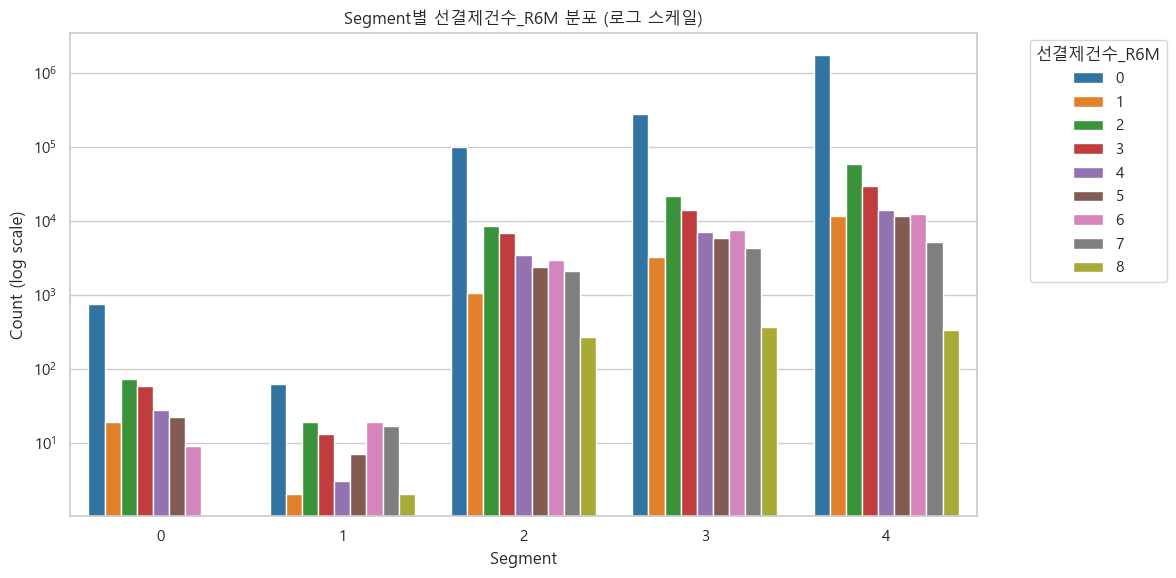

In [406]:
counts_df = df.groupby('Segment')['선결제건수_R6M'].value_counts().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=counts_df, x='Segment', y='count', hue='선결제건수_R6M', palette='tab10')
plt.yscale('log') 
plt.title('Segment별 선결제건수_R6M 분포 (로그 스케일)')
plt.xlabel('Segment')
plt.ylabel('Count (log scale)')
plt.legend(title='선결제건수_R6M', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

In [408]:
# 선결제건수가 7이상이면 not A

In [418]:
# 선결제건수_R3M
col39 = df.groupby('Segment')['선결제건수_R3M'].apply(list).reset_index()
col39['선결제건수_R3M'] = col39['선결제건수_R3M'].apply(lambda x: sorted(set(x)))
col39

,Segment,선결제건수_R3M
0,0,"[0, 1, 2, 3]"
1,1,"[0, 2, 3, 4]"
2,2,"[0, 1, 2, 3, 4]"
3,3,"[0, 1, 2, 3, 4]"
4,4,"[0, 1, 2, 3, 4]"


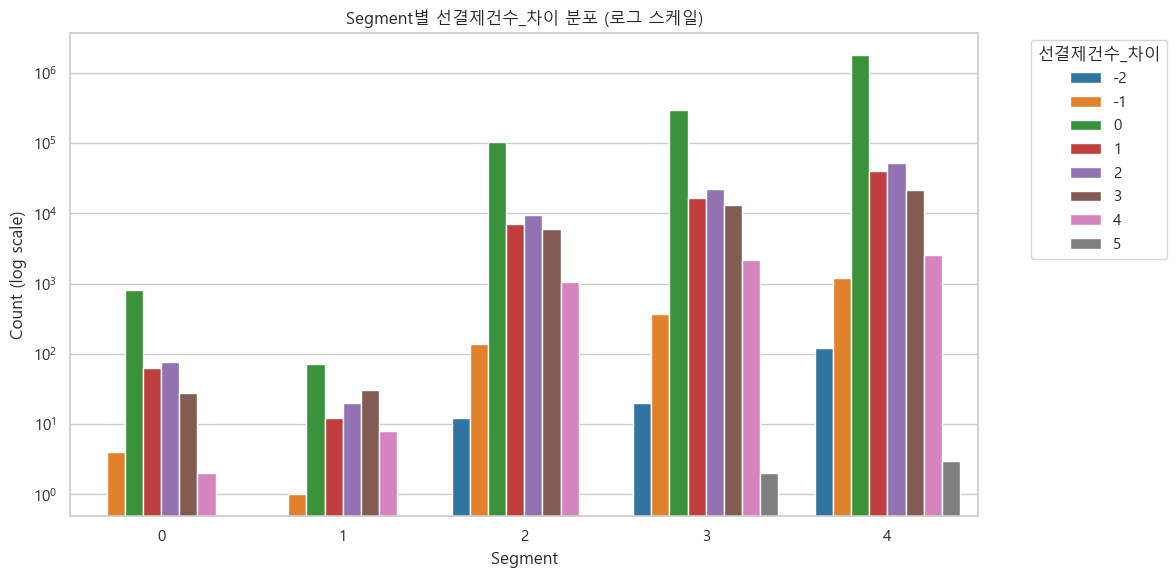

In [420]:
df['선결제건수_차이'] = df['선결제건수_R6M'] - df['선결제건수_R3M']

counts_df = df.groupby('Segment')['선결제건수_차이'].value_counts().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=counts_df, x='Segment', y='count', hue='선결제건수_차이', palette='tab10')
plt.yscale('log') 
plt.title('Segment별 선결제건수_차이 분포 (로그 스케일)')
plt.xlabel('Segment')
plt.ylabel('Count (log scale)')
plt.legend(title='선결제건수_차이', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# 선결제건수_차이가 -2면 C, D, E이고 5 이상이면 D, E

In [423]:
# 연체건수_R6M
col40 = df.groupby('Segment')['연체건수_R6M'].apply(list).reset_index()
col40['연체건수_R6M'] = col40['연체건수_R6M'].apply(lambda x: sorted(set(x)))
col40

,Segment,연체건수_R6M
0,0,"[0, 1, 2, 3, 4, 5, 6]"
1,1,"[0, 2, 3, 4, 5, 6, 7]"
2,2,"[0, 1, 2, 3, 4, 5, 6, 7]"
3,3,"[0, 1, 2, 3, 4, 5, 6, 7, 8]"
4,4,"[0, 1, 2, 3, 4, 5, 6, 7, 8]"


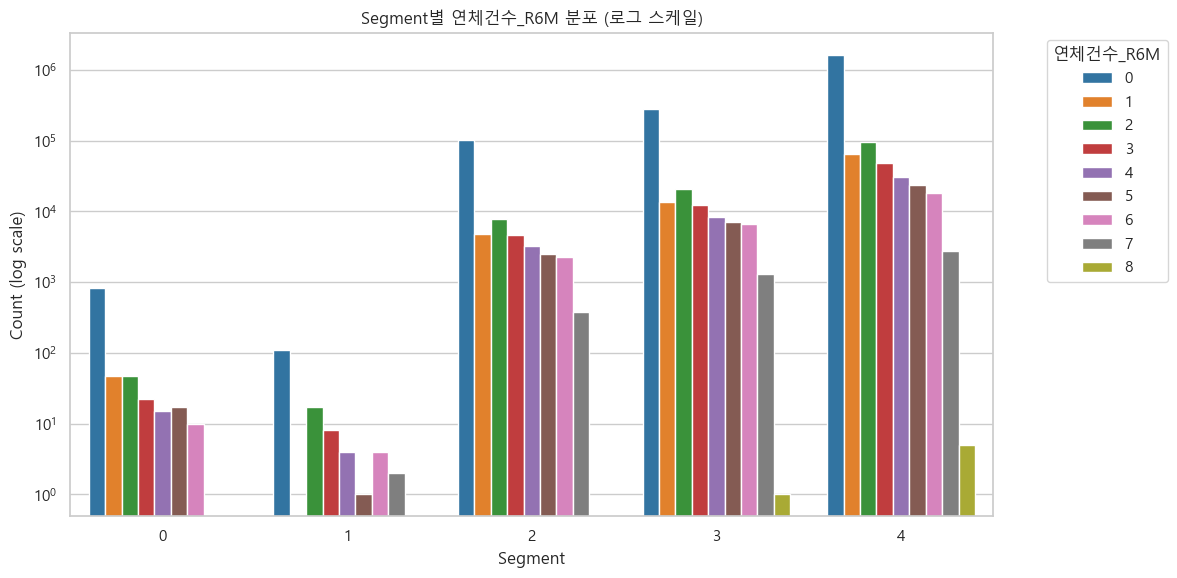

In [425]:
counts_df = df.groupby('Segment')['연체건수_R6M'].value_counts().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=counts_df, x='Segment', y='count', hue='연체건수_R6M', palette='tab10')
plt.yscale('log') 
plt.title('Segment별 연체건수_R6M 분포 (로그 스케일)')
plt.xlabel('Segment')
plt.ylabel('Count (log scale)')
plt.legend(title='연체건수_R6M', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

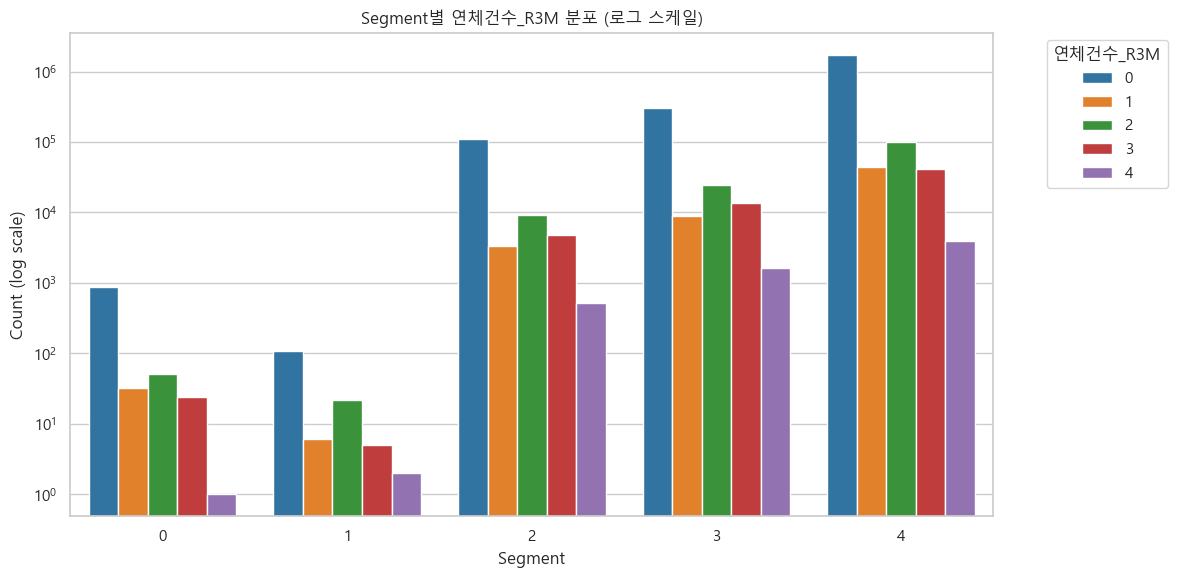

In [427]:
counts_df = df.groupby('Segment')['연체건수_R3M'].value_counts().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=counts_df, x='Segment', y='count', hue='연체건수_R3M', palette='tab10')
plt.yscale('log') 
plt.title('Segment별 연체건수_R3M 분포 (로그 스케일)')
plt.xlabel('Segment')
plt.ylabel('Count (log scale)')
plt.legend(title='연체건수_R3M', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

In [444]:
# 혜택수혜금액_R3M
col42 = df.groupby('Segment')['혜택수혜금액_R3M'].describe()
col42

,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
0,972.0,733.882716,541.417760,0.0,157.75,841.5,1198.00,3327.0
1,144.0,648.451389,508.295683,0.0,133.00,829.0,1101.25,1527.0
2,127590.0,361.270954,397.249885,0.0,0.00,155.0,732.00,3754.0
3,349242.0,236.203601,296.445592,0.0,0.00,131.0,400.00,3253.0
4,1922052.0,82.135866,167.747908,0.0,0.00,0.0,118.00,3092.0


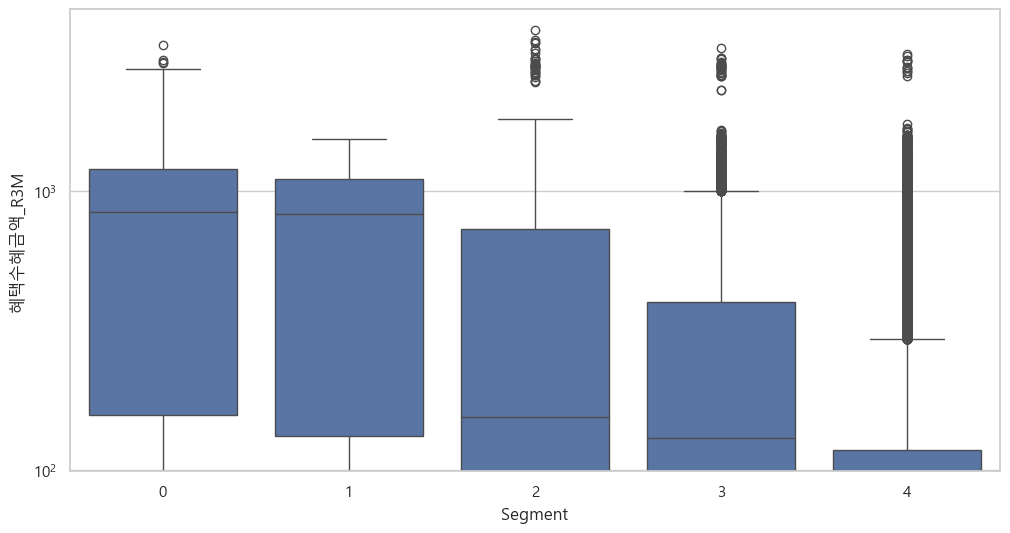

In [433]:
sns.boxplot(x='Segment', y='혜택수혜금액_R3M', data=df)
plt.yscale('log')
plt.show()

In [450]:
# 포인트_마일리지_환산_B0M
col43 = df.groupby('Segment')['포인트_마일리지_환산_B0M'].agg(['min','max'])
col43

,min,max
Segment,,
0,0,517
1,0,469
2,0,607
3,0,574
4,0,519


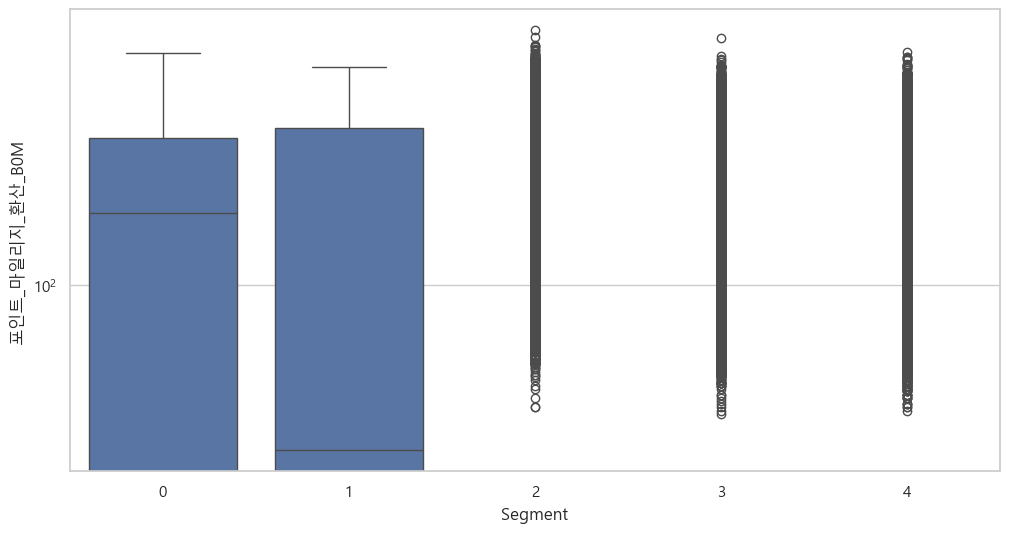

In [452]:
sns.boxplot(x='Segment', y='포인트_마일리지_환산_B0M', data=df)
plt.yscale('log')
plt.show()

In [454]:
col43 = df.groupby('Segment')['포인트_마일리지_환산_B0M'].describe()
col43

,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
0,972.0,166.079218,136.497149,0.0,0.0,166.0,282.00,517.0
1,144.0,144.319444,163.732968,0.0,0.0,31.0,302.75,469.0
2,127590.0,47.385093,95.777895,0.0,0.0,0.0,0.00,607.0
3,349242.0,18.418280,56.730718,0.0,0.0,0.0,0.00,574.0
4,1922052.0,3.317071,22.921057,0.0,0.0,0.0,0.00,519.0


In [456]:
# 혜택수혜금액
col44 = df.groupby('Segment')['혜택수혜금액'].describe()
col44

,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
0,972.0,228.886831,174.370102,0.0,56.0,272.0,295.00,572.0
1,144.0,202.930556,164.594167,0.0,53.0,274.5,293.25,548.0
2,127590.0,117.239666,126.479930,0.0,0.0,54.0,264.00,857.0
3,349242.0,78.967381,98.577059,0.0,0.0,48.0,122.00,811.0
4,1922052.0,27.034641,56.906617,0.0,0.0,0.0,9.00,798.0
